# Task 2 — The Recurrent Neural Network Cell

### Introduction
Recurrent Neural Networks (RNNs) emerged from a simple realization: standard neural networks process every input independently. If you show a standard network the sentence *"I lived in France for ten years, so I speak ____"*, it cannot hold onto the word *"France"* long enough to predict *"French"*. It lacks memory.

To solve this, RNNs introduce a loop that feeds the network's output from the previous step back into itself as an input for the next step. This recurrent loop allows context and history to flow continuously through time.

### Conceptual Diagram: Unrolled RNN
Below is the unrolled structure of an RNN:

![Unrolled RNN](outputs/RNN-unrolled.png)

**How Context Flows Through Time:**
- **Recurrence Loop**: The diagram on the left shows the folded loop. The network processes an input $x_t$ and updates a state $h_t$. The loop indicates that $h_t$ is fed back into the recurrent unit at the next time step.
- **Unrolled Chain**: The diagram on the right unrolls this loop over a sequence $x_0, x_1, ..., x_t$.
  - At step $0$, input $x_0$ and initial state $h_{-1}$ (usually a zero vector) are processed to calculate the hidden state $h_0$.
  - At step $1$, input $x_1$ and **the hidden state vector from the previous step** ($h_0$) are processed together to produce $h_1$.
  - This creates a continuous memory line where early information ($x_0$) travels all the way to the final hidden state output.

---

### What is the "Hidden State" in Simple Words?
Think of the **hidden state** ($h_t$) as the network's **running mental summary** of the story so far. 

As you read a sentence word-by-word, you don't reset your brain at each word. Instead, you maintain a running summary in your head. When you read a new word, you combine it with your existing summary to update your mental state. 

The hidden state is exactly that running mental summary: a list of numbers (a vector) that updates with every new token, carrying memory of the past into the processing of the present.

---

### Recurrent Sequence-to-Sequence Mappings (Types of RNNs)
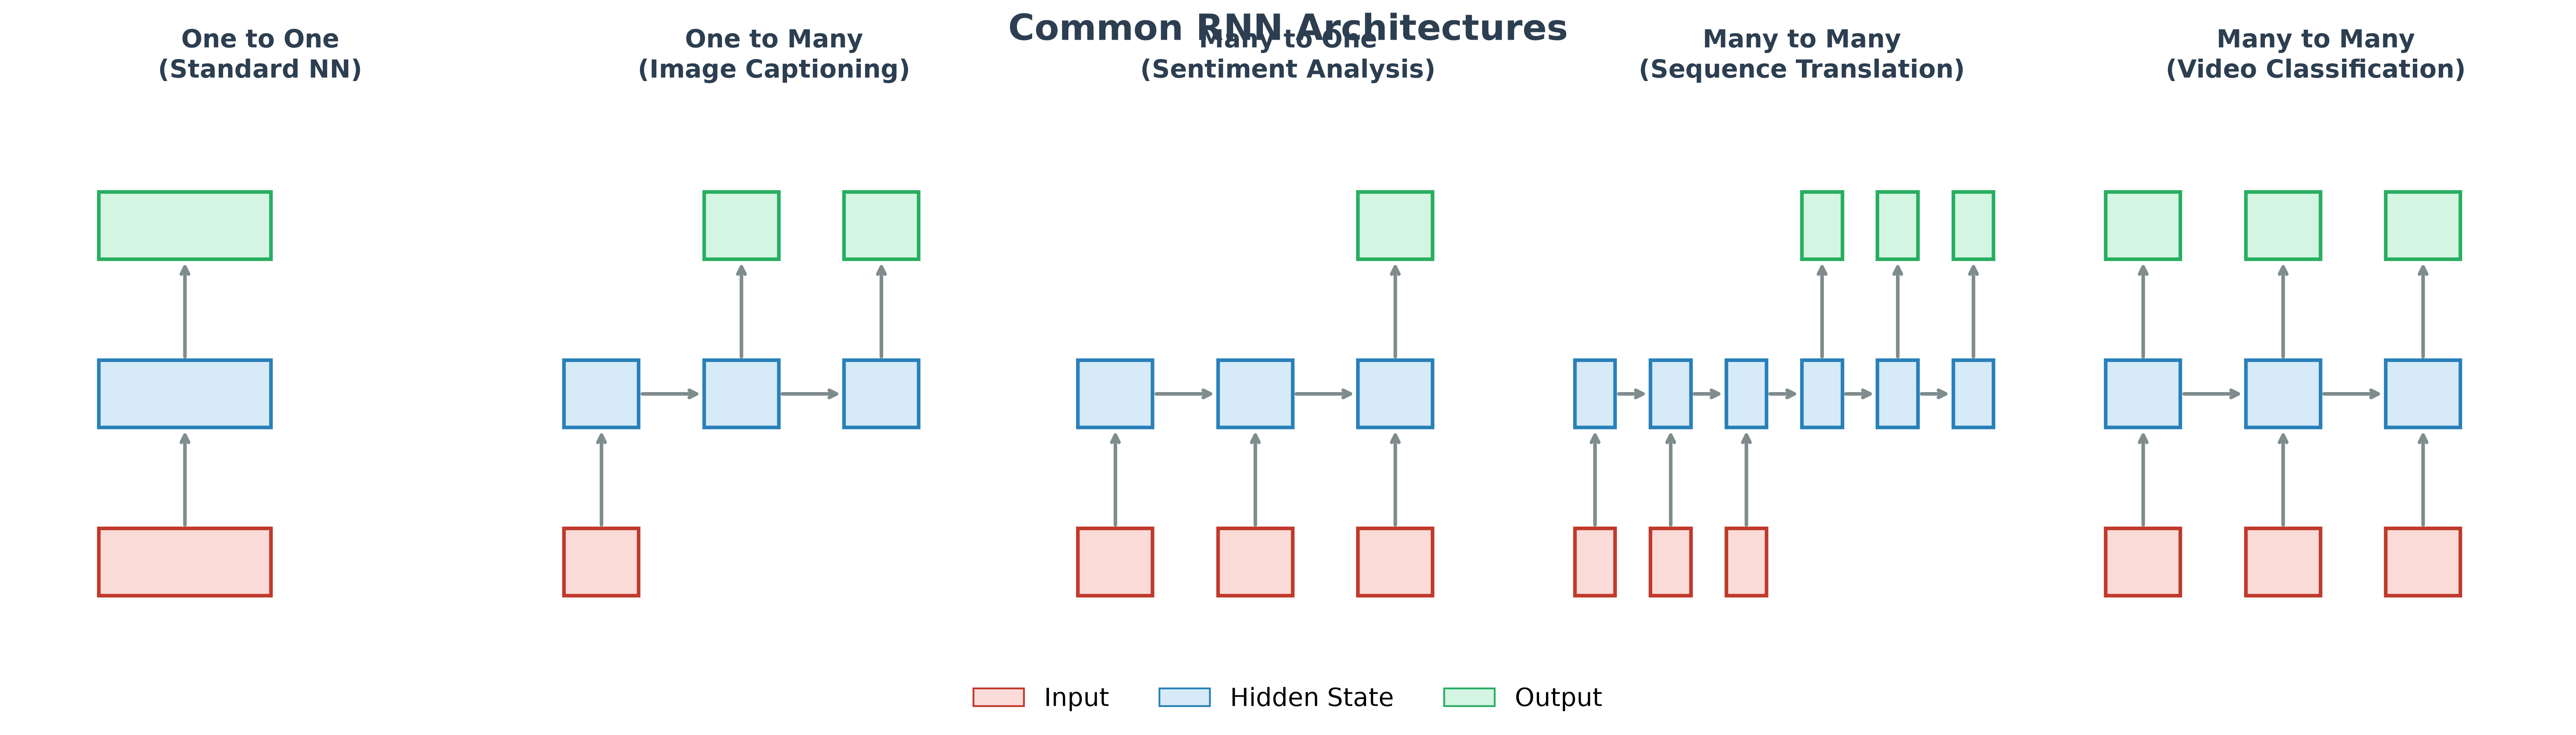

Recurrent Neural Networks are highly versatile because they are not restricted to fixed-size input and output vectors. Depending on the task, we can configure RNNs into different mapping types.

Here are the 5 core types of RNN architectures and their corresponding real-world use cases:

#### 1. One-to-One
*   **Concept**: A standard feed-forward network with a single input mapping to a single output. It has no recurrent memory loop.
*   **Structure**: `[Input] -> [Hidden State] -> [Output]`
*   **Example Use Case**: Standard Image Classification (taking a single image and outputting a single label class).

#### 2. One-to-Many
*   **Concept**: A single static input maps to a sequence of outputs over time. The recurrent hidden state updates at each step to generate consecutive output tokens.
*   **Structure**: `[Input] -> [Hidden_1] -> [Output_1]`
*               `       -> [Hidden_2] -> [Output_2] ...`
*   **Example Use Case**: **Image Captioning** (taking a single image feature vector and generating a sequence of words like *"a dog playing in the grass"*).

#### 3. Many-to-One
*   **Concept**: A sequence of inputs maps to a single final output vector. The network processes the sequence step-by-step to build a final hidden summary, which is then mapped to the output.
*   **Structure**: `[Input_1] -> [Hidden_1]`
*               `[Input_2] -> [Hidden_2] ...`
*               `[Input_T] -> [Hidden_T] -> [Output]`
*   **Example Use Case**: **Sentiment Analysis** (taking a sequence of words in a sentence and classifying it as a single sentiment class: Positive or Negative).

#### 4. Many-to-Many (Synced)
*   **Concept**: A sequence of inputs maps step-by-step to a sequence of outputs of equal length. For every input token processed, the network immediately emits an output token.
*   **Structure**: `[Input_1] -> [Hidden_1] -> [Output_1]`
*               `[Input_2] -> [Hidden_2] -> [Output_2] ...`
*   **Example Use Case**: **Part-of-Speech (POS) Tagging** and **Named Entity Recognition (NER)** (each word in the input sentence gets a corresponding tag class step-by-step).

#### 5. Many-to-Many (Un-synced / Sequence-to-Sequence / Seq2Seq)
*   **Concept**: An input sequence of arbitrary length is mapped to an output sequence of a different arbitrary length. This is achieved using an **Encoder-Decoder** architecture, where an *Encoder* RNN compresses the entire input sequence into a single context vector, and a *Decoder* RNN takes that context vector to generate the output sequence.
*   **Structure**: `[Input_1, Input_2] -> [Encoder Context] -> [Decoder] -> [Output_1, Output_2, Output_3]`
*   **Example Use Case**: **Machine Translation** (translating a French sentence of 7 words into an English sentence of 9 words) and **Text Summarization** (compressing a long article into a short summary).

---

### Step-by-Step Mathematical Mechanics of the RNN Cell
At each time step $t$, the RNN cell updates its hidden state vector ($h_t$) using this formula:
$$h_t = 	anh(W_{hh} h_{t-1} + W_{xh} x_t + b_h)$$

Let's break down each element in a friendly way:
1. **Inputs**:
   - $x_t$: The input vector (like a word embedding) at the current time step.
   - $h_{t-1}$: The hidden state (running summary) from the previous time step.
2. **Trainable Weights (The Learnable Parameters)**:
   - $W_{xh}$: Weights that decide how much attention to pay to the *new word*.
   - $W_{hh}$: Weights that decide how much attention to pay to the *past memory*.
   - $b_h$: The bias vector, which adds offset values.
3. **Activation Function ($	anh$)**:
   - The hyperbolic tangent function squashes all hidden state values into the range $[-1, 1]$. Without this, the numbers in the hidden state would grow exponentially (explode) as we add and multiply them step-by-step.

---

### Backpropagation Through Time (BPTT): How Sequence Models Learn
Training an RNN is like training a standard neural network, but with a twist. Because the hidden states are chained together, we must backpropagate errors backwards through time. This algorithm is called **Backpropagation Through Time (BPTT)**:
1. **Forward Pass**: The network processes the sequence from $t=1$ to $t=T$, generating states $h_1, ..., h_T$ and outputting predictions.
2. **Loss Calculation**: We compare predictions against targets to calculate the total loss.
3. **Unrolling the Gradient**: 
   - Standard backpropagation calculates gradients by moving backward through network layers. 
   - BPTT treats each time step as a separate layer. To calculate weights update at step $t$, we must propagate the error gradient backward from the final step $T$ all the way to $t=1$.
   - This requires repeatedly multiplying the gradient by the hidden-to-hidden weight matrix $W_{hh}$ at each step.
   - If the sequence is long, this repeated multiplication can cause the gradient to shrink to zero (**Vanishing Gradient**) or blow up to infinity (**Exploding Gradient**).

### Core Use Cases
- **Character-Level Language Models**: Generating text one character at a time.
- **Sequence Modeling**: Tracking hidden state dynamics for simple sequence forecasting.



### Step 1 — Manual Unroll of an RNN Cell using NumPy

![RNN Code Mechanics](outputs/rnn_code_implementation.png)



In [1]:
import numpy as np

# Let's define the RNN math:
# h_t = tanh(W_hh * h_prev + W_xh * x_t + b_h)

np.random.seed(42)

# Dimensions
embed_dim = 4    # Size of word embedding vector
hidden_dim = 5   # Size of hidden state vector

# Parameters
W_xh = np.random.randn(hidden_dim, embed_dim) * 0.1
W_hh = np.random.randn(hidden_dim, hidden_dim) * 0.1
b_h = np.zeros((hidden_dim, 1))

# Initialize hidden state h_0
h = np.zeros((hidden_dim, 1))

# Simulate input: a sequence of 5 words (5 embedding vectors)
seq_len = 5
inputs = [np.random.randn(embed_dim, 1) for _ in range(seq_len)]
words = ["The", "RNN", "cell", "remembers", "text"]

print("Starting Manual RNN Step-by-Step Unroll:\n")
for t in range(seq_len):
    x_t = inputs[t]
    
    # Hidden state update formula
    h_next = np.tanh(np.dot(W_hh, h) + np.dot(W_xh, x_t) + b_h)
    
    print(f"Step {t+1} - Word: '{words[t]}'")
    print(f"  Input Vector x_t : {x_t.flatten().round(4)}")
    print(f"  Previous Hidden State h_{t} : {h.flatten().round(4)}")
    print(f"  Updated Hidden State h_{t+1}: {h_next.flatten().round(4)}")
    print("-" * 50)
    
    h = h_next



Starting Manual RNN Step-by-Step Unroll:

Step 1 - Word: 'The'
  Input Vector x_t : [-0.7198 -0.4606  1.0571  0.3436]
  Previous Hidden State h_0 : [0. 0. 0. 0. 0.]
  Updated Hidden State h_1: [ 0.0912  0.2174 -0.0561 -0.1302 -0.0859]
--------------------------------------------------
Step 2 - Word: 'RNN'
  Input Vector x_t : [-1.763   0.3241 -0.3851 -0.6769]
  Previous Hidden State h_1 : [ 0.0912  0.2174 -0.0561 -0.1302 -0.0859]
  Updated Hidden State h_2: [-0.1866 -0.0946  0.189   0.0198  0.3338]
--------------------------------------------------
Step 3 - Word: 'cell'
  Input Vector x_t : [ 0.6117  1.031   0.9313 -0.8392]
  Previous Hidden State h_2 : [-0.1866 -0.0946  0.189   0.0198  0.3338]
  Updated Hidden State h_3: [-0.096   0.0492  0.0419 -0.2988 -0.063 ]
--------------------------------------------------
Step 4 - Word: 'remembers'
  Input Vector x_t : [-0.3092  0.3313  0.9755 -0.4792]
  Previous Hidden State h_3 : [-0.096   0.0492  0.0419 -0.2988 -0.063 ]
  Updated Hidden Stat

### Step 2 — User-Defined Interactive Evaluation Function
Define a custom input sequence of words to manually run the RNN update steps and print hidden states.


In [2]:
# Simple word-to-vector dict for evaluation
toy_vocab = {
    "nlp": np.array([[1.0, 0.5, -0.2, 0.1]]).T,
    "is": np.array([[0.1, 0.9, 0.3, -0.4]]).T,
    "super": np.array([[0.8, -0.1, 0.9, 0.2]]).T,
    "fun": np.array([[-0.5, 0.6, 0.7, 0.8]]).T,
    "easy": np.array([[-0.9, -0.4, 0.1, 0.9]]).T
}

def evaluate_rnn_step(word_list):
    """
    User-defined evaluation function. Runs custom words through the manual RNN cell unroll.
    """
    h_curr = np.zeros((hidden_dim, 1))
    
    print(f"Parsing Sequence: {' -> '.join(word_list)}")
    print("=" * 60)
    
    for t, word in enumerate(word_list):
        word_low = word.lower().strip()
        if word_low not in toy_vocab:
            # Generate random vector for out-of-vocabulary word
            x_t = np.random.randn(embed_dim, 1) * 0.5
            print(f"(Word '{word}' is OOV. Generated random vector.)")
        else:
            x_t = toy_vocab[word_low]
            
        h_next = np.tanh(np.dot(W_hh, h_curr) + np.dot(W_xh, x_t) + b_h)
        
        print(f"Step {t+1} - Word: '{word}'")
        print(f"  Input Vector: {x_t.flatten().round(4)}")
        print(f"  Hidden State: {h_next.flatten().round(4)}")
        print("-" * 60)
        h_curr = h_next

# Run evaluation
evaluate_rnn_step(["nlp", "is", "super", "fun"])



Parsing Sequence: nlp -> is -> super -> fun
Step 1 - Word: 'nlp'
  Input Vector: [ 1.   0.5 -0.2  0.1]
  Hidden State: [ 0.045  -0.059  -0.0152 -0.0426 -0.0814]
------------------------------------------------------------
Step 2 - Word: 'is'
  Input Vector: [ 0.1  0.9  0.3 -0.4]
  Hidden State: [-0.0306  0.0049  0.0331 -0.1961  0.0631]
------------------------------------------------------------
Step 3 - Word: 'super'
  Input Vector: [ 0.8 -0.1  0.9  0.2]
  Hidden State: [ 0.1489  0.1502 -0.0653 -0.103  -0.1975]
------------------------------------------------------------
Step 4 - Word: 'fun'
  Input Vector: [-0.5  0.6  0.7  0.8]
  Hidden State: [ 1.756e-01  1.620e-01 -1.000e-04 -2.776e-01 -6.040e-02]
------------------------------------------------------------
